<a href="https://colab.research.google.com/github/gopaps/MachineLearning/blob/main/TUGAS%20PERBAIKAN/Chapter_5_Perbaikan_Anda_Figo_Haq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 5
membahas cara mengevaluasi dan meningkatkan model machine learning melalui teknik seperti Cross-Validation, Grid Search, dan penggunaan metrik evaluasi. Teknik Cross-Validation membantu kita memahami performa model di berbagai subset data, memastikan bahwa model dapat diandalkan ketika diterapkan pada data baru. Salah satu bentuk yang umum digunakan adalah Stratified k-Fold Cross-Validation, yang menjaga distribusi kelas agar tetap seimbang di setiap lipatan.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
import torch

In [2]:
# Periksa apakah GPU tersedia
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU tersedia. Menggunakan:", torch.cuda.get_device_name(0))
else:
    device = torch.device("cpu")
    print("GPU tidak tersedia. Menggunakan CPU.")


GPU tersedia. Menggunakan: Tesla T4


In [3]:
# Membuat dataset simulasi untuk klasifikasi
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, n_redundant=5, random_state=42)

# Membagi data menjadi set pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Pipeline untuk preprocessing dan model
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])


In [4]:
# Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cross_val_scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring='accuracy')
print(f"Cross-Validation Scores: {cross_val_scores}")
print(f"Mean Cross-Validation Score: {np.mean(cross_val_scores):.2f}")


Cross-Validation Scores: [0.87142857 0.77142857 0.89285714 0.84285714 0.87142857]
Mean Cross-Validation Score: 0.85


In [5]:
# Grid Search untuk Hyperparameter Tuning
param_grid = {
    'model__C': [0.1, 1, 10],
    'model__penalty': ['l2']
}
grid_search = GridSearchCV(pipeline, param_grid, cv=cv, scoring='accuracy')
grid_search.fit(X_train, y_train)

print("Best Parameters dari Grid Search:")
print(grid_search.best_params_)


Best Parameters dari Grid Search:
{'model__C': 1, 'model__penalty': 'l2'}


In [6]:
# Evaluasi Model dengan Parameter Terbaik
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi pada Test Set: {accuracy * 100:.2f}%")


Akurasi pada Test Set: 83.67%


In [7]:
# Laporan Klasifikasi
print("Classification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.79      0.83       149
           1       0.81      0.88      0.84       151

    accuracy                           0.84       300
   macro avg       0.84      0.84      0.84       300
weighted avg       0.84      0.84      0.84       300



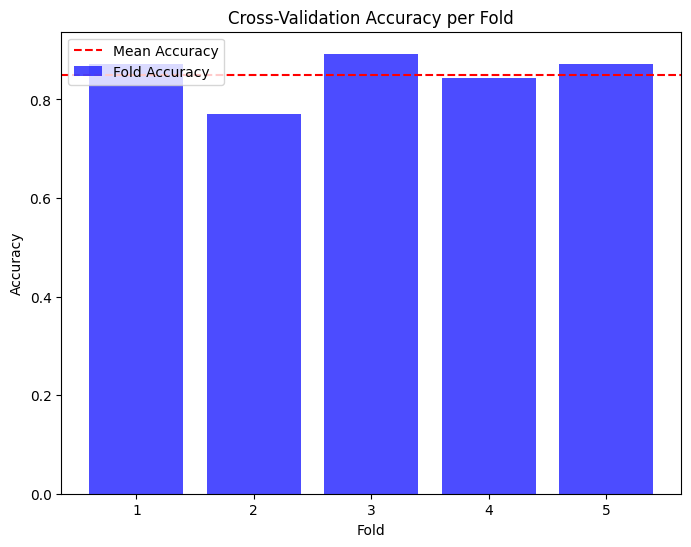

In [8]:
# Visualisasi Hasil Cross-Validation
plt.figure(figsize=(8, 6))
plt.bar(range(1, len(cross_val_scores) + 1), cross_val_scores, alpha=0.7, color='b', label='Fold Accuracy')
plt.axhline(np.mean(cross_val_scores), color='r', linestyle='--', label='Mean Accuracy')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Cross-Validation Accuracy per Fold')
plt.legend()
plt.show()


Selain itu, bab ini menjelaskan pentingnya Grid Search untuk menemukan kombinasi hyperparameter terbaik. Proses ini menguji berbagai konfigurasi parameter model dan memilih yang menghasilkan performa terbaik berdasarkan metrik evaluasi tertentu. Dalam implementasi ini, logistic regression digunakan sebagai model, dengan hyperparameter seperti regulasi C disesuaikan untuk meningkatkan performa.

Pada akhirnya, bab ini menekankan pentingnya memilih metrik evaluasi yang relevan dengan tujuan akhir. Tidak semua masalah klasifikasi bergantung hanya pada akurasi; sering kali, metrik seperti Precision, Recall, atau F1-Score menjadi lebih penting, terutama pada dataset yang tidak seimbang. Dengan alat seperti Grid Search dan Cross-Validation, kita dapat memastikan model yang dihasilkan tidak hanya akurat tetapi juga relevan dengan kebutuhan aplikasi nyata.